# Molecular dynamics simulations of a Lennard-Jones-like liquid

In a classical approximation, interactions between atoms consist of a repulsive term due to electron shell overlap and an attractive term due to dipole-dipole interactions. These terms are typically parametrized by the Lennard-Jones potential. For computational convenience, we use the Wang-Frenkel interaction potential between particles $i$ and $j$ instead


$$
U_{ij}^{\mathrm{WF}} =
\begin{cases}
\epsilon \left[ \left( \frac{\sigma}{r_{ij}} \right)^2 - 1 \right]
\left[ \left( \frac{r_c}{r_{ij}} \right)^2 - 1 \right]^2 & \text{if } r_{ij} < r_c \\
0 & \text{otherwise.}
\end{cases}
$$

with $\sigma$ and $\epsilon$ being phenomenological constants and $r_c$ being the cutoff distance. The distance between molecules is denoted $r_{ij}$. We consider a two-dimensional system of spherical molecules with periodic boundary conditions. The molecules all have the same mass $m$.

## 1. Initialization

### (a)

Write a script to generate the positions of a two-dimensional system of molecules with a packing fraction $\phi$, which is defined as

$$
\phi = \frac{N \pi \sigma^2}{A},
$$
with $N$ being the number of molecules and $A$ being the total surface area of
two-dimensional system. Make sure that the molecules do not overlap because
that would lead to very large energies

In [1]:
#1a
import numpy as np
import matplotlib.pyplot as plt 
import numba as nb

#Constants
sigma = 1.0
rc = 2.5
epsilon = 1.0
phi = 0.3

#Parameter
N = 100

#function to generate positions with the given tensity -> this variant is very slow 
def generate_positions(N, phi, sigma, factor = 1.0, max_trials=100000):
    positions = []
    cnt = 0

    #calculate A for the chosen N and sigma
    A = (N*np.pi*sigma**2) / phi 

    #quadradic field with sidelenght L
    L = np.sqrt(A)

    #calc minimal distance between two moleculecenters
    min_distance = 2* sigma * factor

    #try as long as their are N molecules or max_tails is reached
    while len(positions) < N and cnt < max_trials:
        p = np.array([np.random.uniform(0, L),
                      np.random.uniform(0, L)])

        # check if their is an overlap
        ok = True
        for q in positions:
            if np.linalg.norm(p - q) < min_distance:
                ok = False
                break

        if ok:
            positions.append(p)

        cnt += 1

    # if the number of paricles cannot be reached within the max 
    # nuber of trails stopp with the error 
    if len(positions) < N:
        raise RuntimeError("density not reachable.")

    return np.array(positions), L


#function to generate positions with the given tensity, vectorized 
def generate_positions_v(N, phi, sigma, factor=1.0, max_trials=100000):
    #create empty arry
    positions = np.empty((2, 0))
    cnt = 0

    # calc A / L  for the chosen density
    A = (N * np.pi * sigma**2) / phi
    L = np.sqrt(A)

    # calc minimal distances between the molecule centers
    min_distance = 2 * sigma * factor

    # create N positions
    while positions.shape[1] < N and cnt < max_trials:
        cnt += 1

        #random guess of new positons
        p = np.array([
            np.random.uniform(0, L),
            np.random.uniform(0, L)
        ])

        # first iteration ?
        if positions.shape[1] == 0:
            positions = np.column_stack((positions, p))
            continue

        # deltas from every existing particel to the new guess
        delta = positions - p[:,np.newaxis]

        # calc distance
        distances = np.sqrt(delta[0, :]**2 + delta[1, :]**2)

        # is the particle in the critical region of another particle? 
        if np.all(distances >= min_distance):
            positions = np.column_stack((positions, p))

    # if N not reached -> error message
    if positions.shape[1] < N:
        raise RuntimeError("density not reachable.")
    
    # transpose 
    positions = positions.T
    return positions, L


#positions, L = generate_positions(N, phi, sigma, 1.0, 1000000)
positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)

print("Box length L =", L)
print("Generated positions:")
print(positions)
print(positions.shape)



Box length L = 32.36043187592832
Generated positions:
[[ 3.12798976  8.19657167]
 [16.78638764 25.27014961]
 [18.87325812 23.4430729 ]
 [12.00149299 22.40787733]
 [28.66599854 31.23747092]
 [ 0.85127441 14.13246642]
 [30.97106925 30.99321922]
 [31.46664293 24.33286806]
 [30.77794665  5.67618355]
 [13.98646566 23.28995979]
 [ 4.91049995 31.24001679]
 [24.68667368 21.24968968]
 [18.3482473  13.81913109]
 [28.41983789 14.14085668]
 [11.21956387  4.72597878]
 [15.98578911  6.47736759]
 [18.2362305  27.85141158]
 [24.00197155 19.05864007]
 [ 7.66105843  1.63804718]
 [30.95972887 14.95150301]
 [16.50719558  0.8776151 ]
 [ 0.98893802  6.93285736]
 [ 9.86952489 13.39351167]
 [15.13391483 11.69861835]
 [ 6.98539671 30.07302277]
 [ 2.56844991 31.32117306]
 [10.33808609 20.00111172]
 [23.78196204  0.58896712]
 [24.87843095  9.48430456]
 [14.16132315 19.39741076]
 [12.18902943  1.00803708]
 [31.18060959 22.30422947]
 [13.34487676 27.36289981]
 [28.18519952 17.18548194]
 [13.77733983 31.00322051]
 

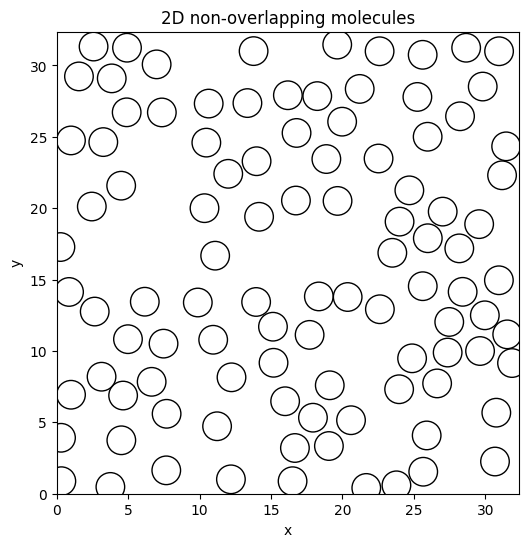

In [2]:
#Testfeld
#plot particles
fig, ax = plt.subplots(figsize=(6, 6))

for x, y in positions:
    circle = plt.Circle((x, y), sigma, fill=False)
    ax.add_patch(circle)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D non-overlapping molecules")
plt.show()

(b) Generate initial velocities for all particles by drawing independent velocities
in every dimension from a Gaussian distribution corresponding to an initial
temperature $T$ . Make sure that the velocity of the center of mass of the system
vanishes.

In [3]:
#1b
# function to generate the velocities
def generate_velocities(N, T, k_B, m):
    # for corresbondig to a Temp use a sigma_v(T)
    # Äquipartitionstheorem 1/2 kb T per dimension
    sigma_v = np.sqrt(k_B*T/m)
    # create velocities
    v = np.random.normal(0.0, sigma_v, size=(N, 2))
    # subtract center-of-mass velocity
    v_cm = np.mean(v, axis=0)
    v_cm_corr = v - v_cm

    return v, v_cm_corr 

# check the function (vanishes v of des center of mass)
N = 100
m =1.0
k_B = 1.0
T = 1.0

v, v_cm_corr = generate_velocities(N, T, k_B, m)
print("Number of Values", np.shape(v))
print("Means of  direction (without COM correction):", np.mean(v, axis=0))
print("Means of  direction (with COM correction):", np.mean(v_cm_corr, axis=0))
#print(positions)


Number of Values (100, 2)
Means of  direction (without COM correction): [-0.07804075  0.10417827]
Means of  direction (with COM correction): [7.99360578e-17 3.27515792e-17]


2 Force calculation
The force between the molecules is given as usual by $f_{ij} = −\nabla U^{WF}_{ij}$ . The forces
are assumed to be pairwise additive.

    (a) Write a script to calculate the force on all particles from the positions of the particles. Take care that periodic boundary conditions are used.


In [4]:
#2a
@nb.njit
def pair_force(vec_rij, epsilon, sigma, rc):
    # absolutvalue of the vector rij
    r = np.sqrt(np.dot(vec_rij,vec_rij))

    # chec if inside the cutoff distance (avoid division 0 )
    if r >= rc or r < 1e-48:
        return np.zeros(2)
    
    # calculate a force
    A = (sigma**2 / r**2) -1.0
    B = (rc**2 / r**2) -1.0
    
    f = vec_rij * (2*epsilon/r**4) * (sigma**2 * B**2 + 2 * A * B * rc**2)
    return f

# test the function
#rc = 10
#i = 0
#j = 6
#rij = positions[i]-positions[j]
#r = np.linalg.norm(rij)
#f = pair_force(rij, epsilon, sigma, rc)
#print(rij)
#print(r)
#print(f)
#print(positions)

# calculate total forces
@nb.njit
def total_forces(positions, L, epsilon, sigma, rc):
    N = len(positions)
    forces = np.zeros_like(positions)
    U_tot = 0
    # seite 79 im scirpt!
    for i in range(N - 1):
        for j in range(i + 1, N):
            rij = positions[i] - positions[j]
            # this is to have periodic poundary conditions
            rij -= L * np.round(rij / L)
            fij  = pair_force(rij, epsilon, sigma, rc)
            # add force to i
            forces[i] += fij
            # same force accts with opposite sign to j
            forces[j] -= fij

    return forces

# Test of te funciton
rc = 1.5
f_tot = total_forces(positions, L, epsilon, sigma, rc)
idx = np.where(np.linalg.norm(f_tot, axis=1) != 0)[0]
print(L)
print(f_tot[idx])


32.36043187592832
[]


        (b) Include a calculation of the total potential energy of the system in the calculation
of the forces

In [5]:
#2b
@nb.njit
def pair_force_potential_Energy(vec_rij, epsilon, sigma, rc):
    # absolutvalue of the vector rij
    r = np.sqrt(np.dot(vec_rij,vec_rij))

    # chec if inside the cutoff distance (avoid division 0 )
    if r >= rc or r < 1e-48:
       return np.zeros(2), 0.0
    
    # calculate a force
    A = (sigma**2 / r**2) -1.0
    B = (rc**2 / r**2) -1.0
    f = vec_rij * (2*epsilon/r**4) * (sigma**2 * B**2 + 2 * A * B * rc**2)

    # calc E Pot
    U = epsilon*A*B**2
    return f, U

# sum up forces and energys 
@nb.njit
def total_forces_Energy(positions, L, epsilon, sigma, rc):
    N = len(positions)
    forces = np.zeros_like(positions)
    U_tot = 0
    # seite 79 im scirpt!
    for i in range(N - 1):
        for j in range(i + 1, N):
            rij = positions[i] - positions[j]
            # this is to have periodic poundary conditions
            rij -= L * np.round(rij / L)
            fij, Uij  = pair_force_potential_Energy(rij, epsilon, sigma, rc)
            # add force to i
            forces[i] += fij
            # same force accts with opposite sign to j
            forces[j] -= fij
            # summ up potential Energy
            U_tot += Uij
    return forces, U_tot

# Test of te funciton
rc = 2.5
f_tot, U_tot = total_forces_Energy(positions, L, epsilon, sigma, rc)
idx = np.where(np.linalg.norm(f_tot, axis=1) != 0)[0]
print(L)
print(f_tot[idx])
print(U_tot)


32.36043187592832
[[ 9.01044969e-01 -8.09271161e-01]
 [ 5.51539564e-01  2.45093236e-01]
 [ 2.60918376e-01 -2.76476357e-02]
 [ 1.76315696e-01 -1.84175233e-01]
 [-2.60918376e-01  2.76476357e-02]
 [ 1.44899351e+00 -6.67378980e-01]
 [-5.51539564e-01 -2.45093236e-01]
 [-9.33946443e-01  9.09758509e-01]
 [-9.12274112e-02 -2.91928090e-01]
 [ 1.15416023e+00 -2.30230891e-02]
 [ 1.44340767e-01 -5.28924395e-01]
 [ 3.19438166e-01 -1.88871651e-01]
 [-9.87956829e-01  2.84656101e-02]
 [ 2.60749669e-01 -2.74266041e-01]
 [ 1.23623885e-01 -4.49615902e-02]
 [ 1.68171595e-02  2.37340574e-01]
 [ 1.47470182e-02  8.71228003e-03]
 [-4.76193439e-01  6.99306352e-01]
 [-1.35456540e-01  7.61854638e-02]
 [ 1.12520709e+00  1.08169446e+00]
 [-2.03463832e-01  2.22576969e-02]
 [-6.72040763e-02 -2.03407580e-01]
 [ 1.43462544e-01  1.01748157e+00]
 [ 9.02084870e-02  4.98893186e-01]
 [-2.19447609e-01 -2.40005509e+00]
 [-4.20667202e-01 -2.35881797e-01]
 [ 4.17279830e-02 -1.39977207e-04]
 [ 7.99106443e-02  1.90665803e-01]
 [

(c) Evaluate the scaling of computational cost of the force calculation with the num-
ber of particles $N$ .

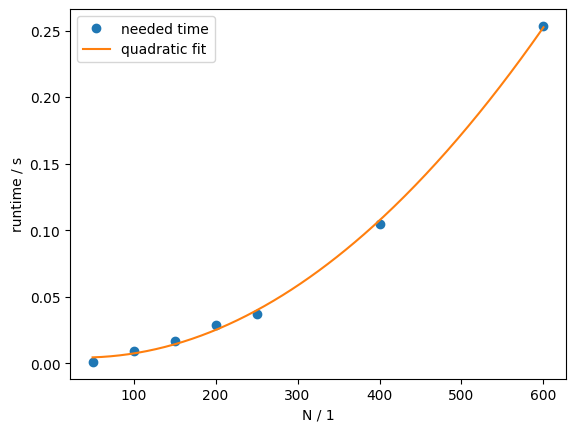

Fit: t(N) = a*N^2 + b*N + c
a = 7.84032849611892e-07
b = -5.88041460620992e-05
c = 0.0054849724277829396


In [6]:
#2c
import time
N_values = [50,100,150,200,250,400,600] 
times = []
repeats = 2 # per N_value

for N in N_values:
    positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)
    # list for times with same N to calc mean
    t_list =[]
    # do this for the number of repeats
    for _ in range(repeats):
        t0 = time.perf_counter()
        f  = total_forces(positions, L, epsilon, sigma, rc)
        t1 = time.perf_counter()
        t_list.append(t1-t0)
    # calc mean of all times for same n
    times.append(np.mean(t_list)) 

# crate a fit to show its quatratic 
times = np.array(times)
N_values_plot = np.array(N_values)
coeff = np.polyfit(N_values_plot, times, 2)
a, b, c = coeff
N_fit = np.linspace(N_values_plot.min(), N_values_plot.max(), 300)
t_fit = a * N_fit**2 + b * N_fit + c

plt.plot(N_values_plot, times, 'o', label='needed time')
plt.plot(N_fit, t_fit, '-', label='quadratic fit')
plt.xlabel('N / 1')
plt.ylabel('runtime / s')
plt.legend()
plt.show()

print("Fit: t(N) = a*N^2 + b*N + c")
print("a =", a)
print("b =", b)
print("c =", c)


3 Integration of the equations of motion

(a)

Nondimensionalize the equations and pick a sensible time step in terms of $\sigma$, $\epsilon$ and the particle mass $m$.

The velocity-Verlet algorithm for positions $r$, velocities $v$ and forces $f$ consists of the following steps:

$$
v\left(t + \frac{\Delta t}{2}\right) = v(t) + \frac{f(t)}{2m}\Delta t
$$

$$
r(t + \Delta t) = r(t) + v\left(t + \frac{\Delta t}{2}\right)\Delta t
$$

$$
f(t + \Delta t) = f(r(t + \Delta t))
$$

$$
v(t + \Delta t) = v\left(t + \frac{\Delta t}{2}\right) + \frac{f(t+\Delta t)}{2m}\Delta t
$$


In [7]:
#3a
# no code required

Die Antwort sind mehr oder weniger nur Formeln

(b)

Implement the velocity-Verlet algorithm to solve the equations of motion.

In [8]:
#3b
@nb.njit
def velocity_verlet(pos, vel, L, n_steps, dt, epsilon, sigma, rc, m):
    # use N of pos
    N = len(pos)

    # calculate forces and Potential energy
    forces, U = total_forces_Energy(pos, L, epsilon=epsilon, sigma=sigma, rc=rc)

    # initalize arrays for energys
    E_kin_hist = np.zeros(n_steps)
    E_pot_hist = np.zeros(n_steps)
    E_tot_hist = np.zeros(n_steps)
    T_hist = np.zeros(n_steps)
    pos_hist = np.zeros((n_steps, N, 2))


    for i in range(n_steps):
        # calc fist velocity halfstep
        vel_half = vel + 0.5 * forces / m * dt

        # Full-step position
        pos = pos + vel_half * dt

        # Pos Modulo L is used for periodic boundary conditions
        pos = pos % L

        # New forces forces after step
        forces_new, U = total_forces_Energy(pos, L, epsilon=epsilon, sigma=sigma, rc=rc)

        # Full-step velocity
        vel = vel_half + 0.5 * forces_new / m * dt

        # Update forces
        forces = forces_new

        # calc kinetic enerty
        E_kin = 0.5 * m * np.sum(vel**2)

        # Temperature in 2D
        # degrees of freedom = 2N - 2
        dof = 2 * N - 2
        T = 2 * E_kin / dof

        E_kin_hist[i] = E_kin
        E_pot_hist[i] = U
        E_tot_hist[i] = E_kin + U
        T_hist[i] = T

        pos_hist[i] = pos

        if i % 100 == 0:
            print(i, "/",n_steps)

    return pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist

(c)

Calculate the kinetic energy at every integer time step and plot the total energy and the temperature as a function of time.

0 / 1000
100 / 1000
200 / 1000
300 / 1000
400 / 1000
500 / 1000
600 / 1000
700 / 1000
800 / 1000
900 / 1000


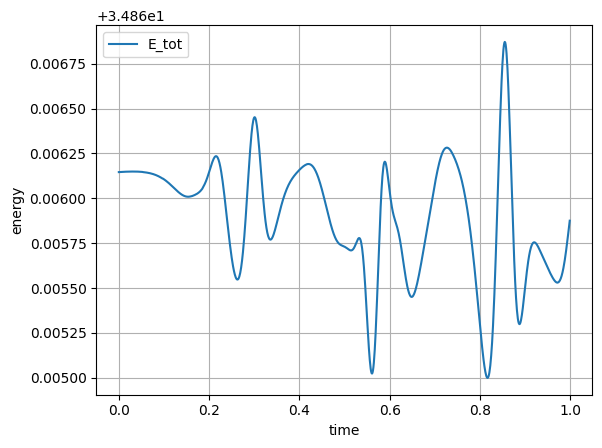

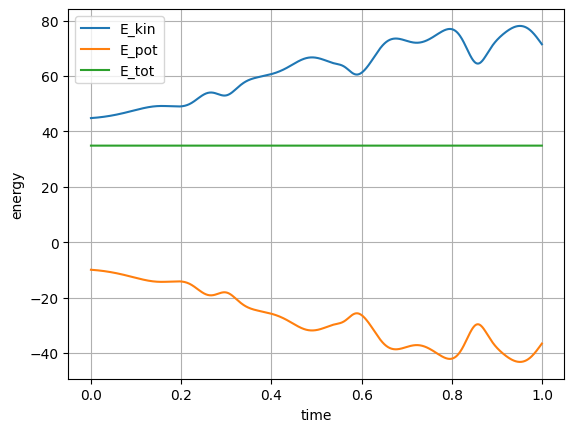

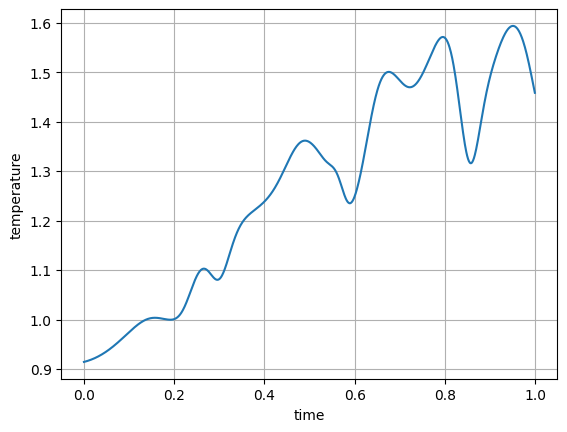

In [9]:
#3c
# Example parameters
N = 50
sigma = 1.0
epsilon = 1.0
m = 1.0
rc = 2.5
phi = 0.3
dt = 0.001
n_steps = 1000

positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)
_, v = generate_velocities(N, 1, 1, m)

pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist = velocity_verlet(
    positions,v, L,
    n_steps=n_steps,
    dt=dt,
    epsilon=epsilon,
    sigma=sigma,
    rc=rc,
    m=m
)

time = np.arange(n_steps) * dt

plt.figure()
plt.plot(time, E_tot_hist, label="E_tot")
plt.xlabel("time")
plt.ylabel("energy")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(time, E_kin_hist, label="E_kin")
plt.plot(time, E_pot_hist, label="E_pot")
plt.plot(time, E_tot_hist, label="E_tot")
plt.xlabel("time")
plt.ylabel("energy")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(time, T_hist)
plt.xlabel("time")
plt.ylabel("temperature")
plt.grid()
plt.show()

# Computer Simulations  
## 4th problem set
# Molecular dynamics simulations in the canonical ensemble

In the canonical ensemble, the temperature $T$ is kept constant in the thermodynamic limit. In a finite-sized system, that means that the temperature will fluctuate around $T$ with a well-defined variance. One way to set the temperature in the canonical ensemble is using the Heyes thermostat, which works as follows.

During the simulation, we will occasionally attempt to rescale all velocities by a factor $z$, with $-\ln z$ being evenly distributed in an interval between $-\Delta$ and $\Delta$. After rescaling, the total kinetic energy has increased or decreased by a factor $z^2$.

The distribution of the total kinetic energy $E_k$ in $d$ dimensions should follow
$$
P(E_k) =
C
\left(\sqrt{E_k}\right)^{d(N-1)}
\exp\left(
-\frac{E_k}{k_B T}
\right).
$$

To attain this distribution in the simulation, we accept the rescaling move with a probability

$$
p_{\mathrm{acc}}(E_k \to z^2 E_k)
=
\min\left(
1,
z^{d(N-1)}
\exp\left(
-\frac{E_k(z^2 - 1)}{k_B T}
\right)
\right).
$$

---

# 1. Thermostat

## (a)

Implement the Heyes thermostat for the Lennard-Jones-like simulation system from the 3rd problem sheet. Take care that the algorithm is still time reversible by putting the rescaling between the two half-step updates of the velocity $\mathbf{v}$ in the velocity Verlet algorithm.

Pick $\Delta$ relatively small, in order to disturb the dynamics as little as possible. It is not necessary, but also not wrong, to apply the thermostat every time step.

## (b) Calculate the kinetic temperature

$$
T_k(t) =
\frac{
\sum_{i=1}^{N} m_i v_i^2(t)
}{
k_B N_f
},
$$

with

$$
N_f = dN - d - 1
$$

being the number of degrees of freedom. Plot the temperature as a function of time for two different set temperatures $T$.


T_set = 3.0
mean T after equilibration = 2.949521517940395
std T after equilibration  = 0.28673399380810805
acceptance rate = 0.0786

T_set = 5.0
mean T after equilibration = 4.96951094530529
std T after equilibration  = 0.5464905399349383
acceptance rate = 0.0818



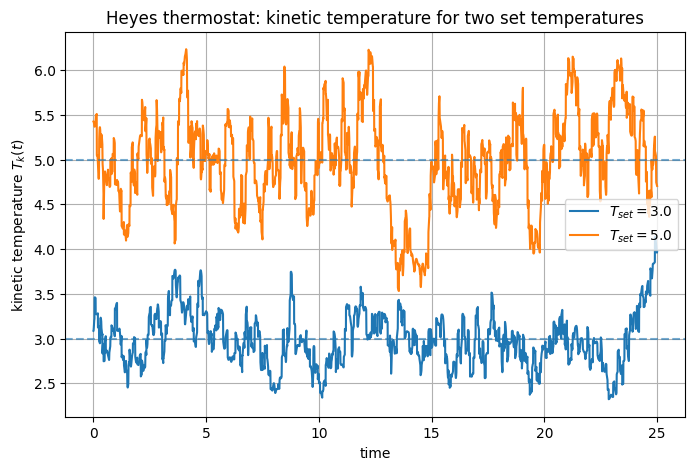

In [10]:
# 1a
@nb.njit
def heyes_thermostat(v, set_T, Delta, m, kb):
    # get N and d from the shape of v
    N, d = v.shape

    # current kinetic energy
    E_k = 0.5 * m * np.sum(v**2)

    # get z, where -ln(z) is uniformly distributed in [-Delta, Delta]
    x = np.random.uniform(-Delta, Delta)
    z = np.exp(-x)

    # acceptance probability as given in the exercise
    p_acc = z**(d * (N - 1)) * np.exp(-E_k * (z**2 - 1.0) / (kb * set_T))

    # limit probability to max 1
    if p_acc > 1.0:
        p_acc = 1.0

    # accept or reject
    if np.random.rand() < p_acc:
        return z * v, True
    else:
        return v, False
    

# now put this function in the velocity verlet from 3. exercice
@nb.njit
def velocity_verlet_with_heyes(pos, vel, L, n_steps, dt, epsilon, sigma, rc, m, set_T, Delta):
    # use N from pos
    N = len(pos)
    d = 2
    kb = 1.0

    # calculate initial forces and potential energy
    forces, U = total_forces_Energy(pos, L, epsilon, sigma, rc)

    # initialize arrays for energies and temperature
    E_kin_hist = np.zeros(n_steps)
    E_pot_hist = np.zeros(n_steps)
    E_tot_hist = np.zeros(n_steps)
    T_hist = np.zeros(n_steps)
    pos_hist = np.zeros((n_steps, N, 2))
    accepted_hist = np.zeros(n_steps, dtype=np.bool_)

    for i in range(n_steps):
        # default value, if thermostat is not used in this step
        accepted = False

        # first velocity half-step
        vel_half = vel + 0.5 * forces / m * dt

        # Heyes thermostat after first half-step
        if i % 10 == 0:
            vel_half, accepted = heyes_thermostat(
                vel_half,
                set_T,
                Delta,
                m,
                kb
            )

        # full-step position
        pos = pos + vel_half * dt

        # periodic boundary conditions
        pos = pos % L

        # new forces after position update
        #forces, U = total_forces_Ene
        forces_new, U = total_forces_Energy(
            pos,
            L,
            epsilon,
            sigma,
            rc
        )

        # second velocity half-step
        vel = vel_half + 0.5 * forces_new / m * dt
        #vel = vel_half + 0.5 * forces / m * dt

        # update forces
        forces = forces_new

        # kinetic energy
        E_kin = 0.5 * m * np.sum(vel**2)

        # kinetic temperature according to the exercise
        dof = d * N - d - 1
        T = 2 * E_kin / (kb * dof)

        E_kin_hist[i] = E_kin
        E_pot_hist[i] = U
        E_tot_hist[i] = E_kin + U
        T_hist[i] = T
        pos_hist[i] = pos
        accepted_hist[i] = accepted

        # besser für Speed auskommentieren
        # if i % 100 == 0:
        #     print(i, "/", n_steps)

    return pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist, accepted_hist




# Parameters
N = 100
sigma = 1.0
epsilon = 1.0
m = 1.0
rc = 2.0
phi = 0.3
dt = 0.005
n_steps = 5000

Delta = 0.05

# Two set temperatures required in 1b
T_values = [3.0, 5.0]

time = np.arange(n_steps) * dt

plt.figure(figsize=(8, 5))

for set_T in T_values:
    # Generate new initial configuration for each temperature
    positions, L = generate_positions_v(N, phi, sigma, 1.0, 1000000)
    _, v = generate_velocities(N, set_T, 1, m)

    pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist, accepted_hist = velocity_verlet_with_heyes(
        positions,
        v,
        L,
        n_steps=n_steps,
        dt=dt,
        epsilon=epsilon,
        sigma=sigma,
        rc=rc,
        m=m,
        set_T=set_T,
        Delta=Delta
    )

    # Plot kinetic temperature
    plt.plot(time, T_hist, label=fr"$T_{{set}} = {set_T}$")

    # Print simple diagnostics after equilibration
    start = int(0.2 * n_steps)
    print("T_set =", set_T)
    print("mean T after equilibration =", np.mean(T_hist[start:]))
    print("std T after equilibration  =", np.std(T_hist[start:]))
    print("acceptance rate =", np.mean(accepted_hist))
    print()

# Add horizontal reference lines for the two set temperatures
for set_T in T_values:
    plt.axhline(set_T, linestyle="--", alpha=0.6)

plt.xlabel("time")
plt.ylabel(r"kinetic temperature $T_k(t)$")
plt.title("Heyes thermostat: kinetic temperature for two set temperatures")
plt.legend()
plt.grid()
plt.show()

# 2. Phase diagram

Depending on the density and the temperature, the system can be in the solid, liquid, or gas phase. To find in which phase the system is, we calculate the radial distribution function in two dimensions

$$
g(r)
=
\frac{2L^2}{N^2}
\sum_i
\sum_{j>i}
\frac{\delta(r_{ij} - r)}{2\pi r},
$$

with $L$ being the box length and $r_{ij}$ the distance between particles $i$ and $j$.

The delta function can be calculated as

$$
\delta(r_{ij} - r)
=
\varepsilon^{-1}
$$

if

$$
|r_{ij} - r| < \varepsilon
$$

and zero otherwise.

## (a)

Implement the calculation of $g(r)$ in the simulation, averaging over time. Note that the evaluation can be included in the force calculation to reduce the computational load.

In the solid phase, $g(r)$ shows a long range order of continuous oscillations. In the liquid phase, $g(r)$ exhibits a short range order, oscillating but reducing to

$$
g(r) = 1
\quad \text{for} \quad
r \to \infty.
$$

In the gas phase, $g(r)$ shows at most a single peak.

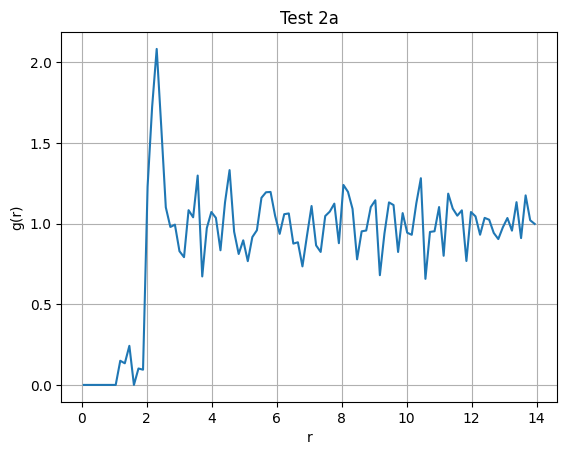

In [11]:
#2a
#first we need a function to calculate the radial distribution g(r)
def calc_radial_dist(pos, L, N_g_values):
    N_pos = pos.shape[0]
    g = np.zeros(N_g_values)

    # calculate maximum useful distance for the radial distribution
    r_max = L / 2.0

    # width of one radial bin
    dr = r_max / N_g_values

    # bin centers for the r-axis
    r = (np.arange(N_g_values) + 0.5) * dr

    # loop over all particle pairs
    for i in range(N_pos):
        for j in range(i + 1, N_pos):

            # distance vector between particle i and particle j
            dx = pos[i, 0] - pos[j, 0]
            dy = pos[i, 1] - pos[j, 1]

            # minimum image convention for periodic boundary conditions
            dx -= L * np.round(dx / L)
            dy -= L * np.round(dy / L)

            # absolute distance
            rij = np.sqrt(dx**2 + dy**2)

            # only count distances up to L/2
            if rij < r_max:

                # find corresponding radial bin
                bin_index = int(rij / dr)

                # safety check
                if bin_index < N_g_values:

                    # radius at the center of this bin
                    r_bin = r[bin_index]

                    # contribution according to delta approximation
                    g[bin_index] += 1.0 / (2.0 * np.pi * r_bin * dr)

    # normalization of g(r) in two dimensions
    g *= 2.0 * L**2 / N_pos**2

    return r, g 


N_test = 100
phi_test = 0.4
sigma = 1.0
N_g_values = 100
# generate start positions
pos_test, L_test = generate_positions_v(
    N_test,
    phi_test,
    sigma,
    factor=1.0,
    max_trials=1000000
)
r_test, g_test = calc_radial_dist(pos_test, L_test, N_g_values)
plt.figure()
plt.plot(r_test, g_test)
plt.xlabel("r")
plt.ylabel("g(r)")
plt.title("Test 2a")
plt.grid()
plt.show()

## (b)

Calculate the radial distribution function for a few different values of the packing fraction $\phi$ and the temperature $T$.

Try to find three combinations of $T$ and $\phi$ that describe systems in the gas, liquid, and solid phase, respectively.

Plot the $g(r)$ and a snapshot of these three simulation systems.

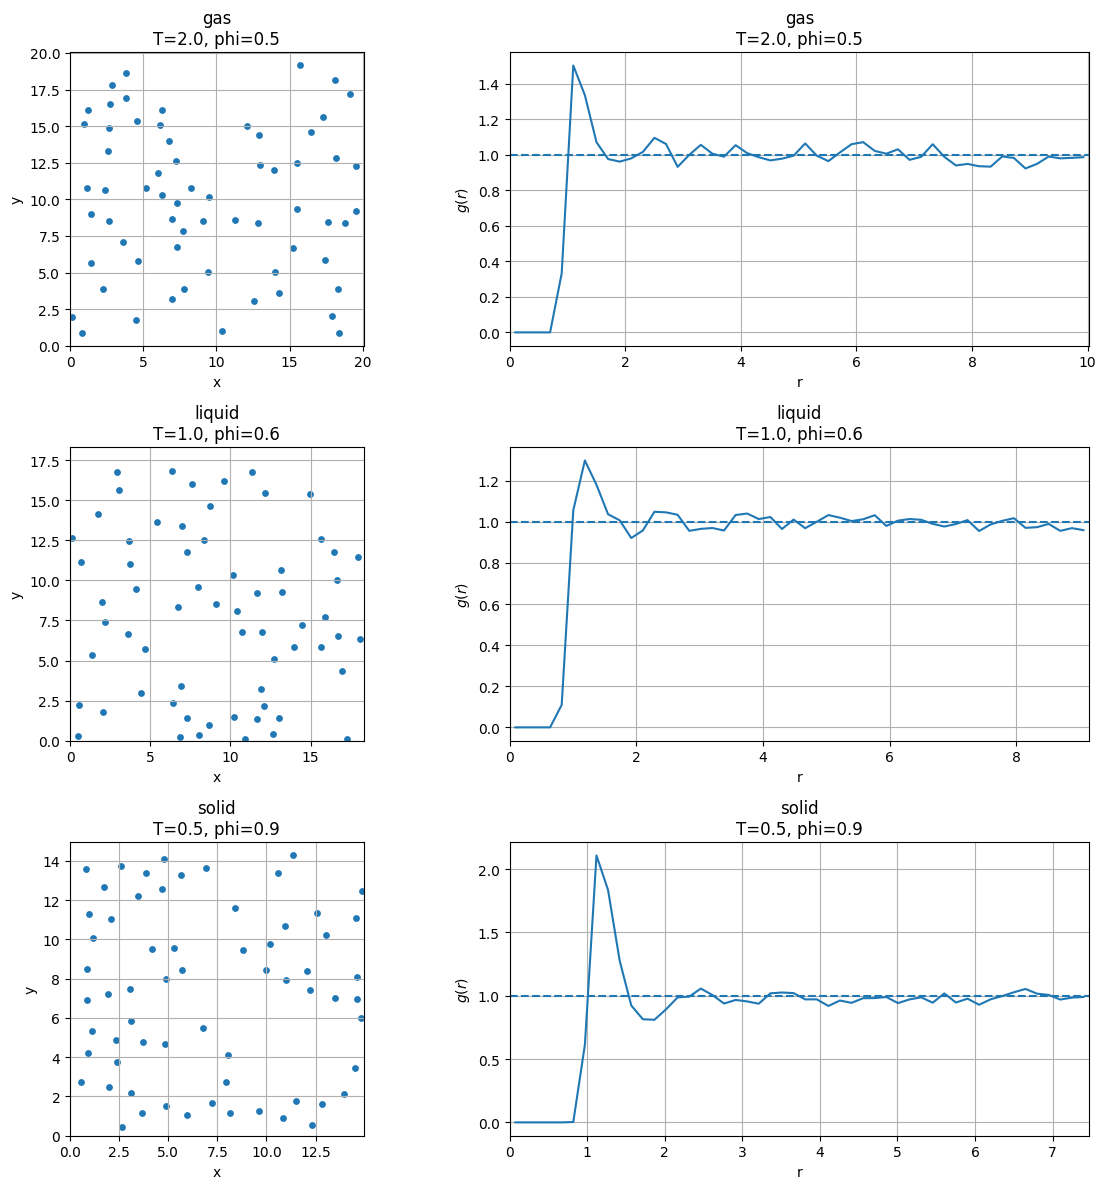

In [31]:
# 2b
simulation_cases = [
 {"label": "gas", "T": 2.0, "phi": 0.5},
 {"label": "liquid", "T": 1.0, "phi": 0.6},
 {"label": "solid", "T": 0.5, "phi": 0.9},
]


# helper function: make sure position array has shape (N, 2)
def ensure_Nx2(pos):
    pos = np.asarray(pos)

    if pos.shape[1] == 2:
        return pos

    if pos.shape[0] == 2:
        return pos.T

    raise ValueError(f"Position array has unexpected shape: {pos.shape}")


def generate_positions_ordered_v(N, phi, sigma):
    # calc A / L for the chosen density
    A = (N * np.pi * sigma**2) / phi
    L = np.sqrt(A)

    # create empty array
    positions = np.zeros((N, 2))

    # number of columns and rows
    numberOfColumns = int(np.ceil(np.sqrt(N)))
    numberOfRows = int(np.ceil(N / numberOfColumns))

    # grid spacing
    dx = L / numberOfColumns
    dy = L / numberOfRows

    particleIndex = 0

    for row in range(numberOfRows):
        for col in range(numberOfColumns):

            if particleIndex < N:
                x = (col + 0.5) * dx
                y = (row + 0.5) * dy

                # shift every second row
                if row % 2 == 1:
                    x += 0.5 * dx

                # periodic wrapping in x direction
                if x >= L:
                    x -= L

                positions[particleIndex, 0] = x
                positions[particleIndex, 1] = y

                particleIndex += 1

    return positions, L

N = 64
sigma = 1.0
epsilon = 1.0
rc = 2.0 * sigma
m = 1.0
dt = 0.005
n_steps = 2000
N_g_values = 50
Delta = 0.01

equilibration_steps = n_steps // 2 # equilibrium to the half
sample_interval = 1 # 1 => calc g in every iteration


fig, axs = plt.subplots(len(simulation_cases), 2, figsize=(12, 12), squeeze=False)

for row, case in enumerate(simulation_cases):

    label = case["label"]
    T_set = case["T"]
    phi = case["phi"]

    # generate initial configuration
    if label == "solid":
        pos, L = generate_positions_ordered_v(N, phi, sigma)
    else:
        pos, L = generate_positions_v(
            N,
            phi,
            sigma,
            factor=1.0,
            max_trials=1000000
        )

    #pos_init = pos.copy()

    # plt.figure()
    # plt.scatter(pos[:, 0], pos[:, 1], s=15)
    # plt.xlim(0, L)
    # plt.ylim(0, L)
    # plt.gca().set_aspect("equal")
    # plt.grid()
    # plt.title("Initial solid configuration")
    # plt.show()

    # make sure pos has shape (N, 2)
    pos = ensure_Nx2(pos)

    # generate initial velocities
    #_, vel = generate_velocities(N, T_set, dim, m)
    _, vel = generate_velocities(N, T_set, 1.0, m)

    # run complete simulation once
    pos, vel, pos_hist, E_kin_hist, E_pot_hist, E_tot_hist, T_hist, accepted_hist = velocity_verlet_with_heyes(
        pos,
        vel,
        L,
        n_steps=n_steps,
        dt=dt,
        epsilon=epsilon,
        sigma=sigma,
        rc=rc,
        m=m,
        set_T=T_set,
        Delta=Delta
    )

    # make sure final pos has shape (N, 2)
    pos = ensure_Nx2(pos)

    # average g(r) after equilibration
    g_sum = np.zeros(N_g_values)
    n_samples = 0

    #@nb.njit
    for step in range(equilibration_steps, n_steps, sample_interval):

        pos_sample = ensure_Nx2(pos_hist[step])

        r_values, g = calc_radial_dist(pos_sample, L, N_g_values)

        g_sum += g
        n_samples += 1

    g_average = g_sum / n_samples

    # final particle snapshot
    axs[row, 0].scatter(pos[:, 0], pos[:, 1], s=15)
    axs[row, 0].set_xlim(0, L)
    axs[row, 0].set_ylim(0, L)
    axs[row, 0].set_aspect("equal")
    axs[row, 0].set_title(f"{label}\nT={T_set}, phi={phi}")
    axs[row, 0].set_xlabel("x")
    axs[row, 0].set_ylabel("y")
    axs[row, 0].grid()

    # radial distribution function
    axs[row, 1].plot(r_values, g_average)
    axs[row, 1].axhline(1.0, linestyle="--")
    axs[row, 1].set_title(f"{label}\nT={T_set}, phi={phi}")
    axs[row, 1].set_xlabel("r")
    axs[row, 1].set_ylabel(r"$g(r)$")
    axs[row, 1].set_xlim(0, L / 2.0)
    axs[row, 1].grid()

plt.tight_layout()
plt.show()

# 3. Diffusion constant

For long times $t$, the diffusion constant $D$ can be evaluated from the mean square displacement

$$
\Delta r(t)^2
=
\left\langle
|\mathbf{r}(t) - \mathbf{r}(0)|^2
\right\rangle
$$

as

$$
\Delta r(t)^2 = 2dDt.
$$

## (a)

Estimate the diffusion constant $D$ for a system in the liquid state from the mean square displacement.

Make a plot of $\Delta r(t)^2$ as a function of time.

What happens for short times?

Alternatively, the diffusion constant can be calculated from the velocity autocorrelation function

$$
D
=
\frac{1}{d}
\int_0^\infty
dt\,
\left\langle
\mathbf{v}(0) \cdot \mathbf{v}(t)
\right\rangle.
$$

## (b)

Plot the velocity autocorrelation function.

Calculate $D$ from the autocorrelation function and compare it to your result using the mean square displacement.

Note that the autocorrelation of a variable $A(t)$ can be calculated using the Fourier transform,

$$
\tilde{a}(\omega)
=
\int_0^\theta
dt\,
A(t)
\exp(i\omega t),
$$

$$
G_A(\omega)
=
\lim_{\theta \to \infty}
\frac{1}{2\pi \theta}
\left\langle
|\tilde{a}(\omega)|^2
\right\rangle,
$$

$$
\left\langle
A(0)A(\tau)
\right\rangle
=
\int_{-\infty}^{\infty}
d\omega\,
G_A(\omega)
\exp(-i\omega \tau).
$$

In [13]:
#clacculaten deltar_squared aus der angabe
@nb.njit
def calc_msd(r,  r_initial):
    delta_r = r-r_initial
    delta_r_squared_sum = np.sum(delta_r**2,axis = 1) 
    return  np.mean(delta_r_squared_sum)


#funcition to estimate Difusionconstant via linear Fit
def estimate_D(t, msd, dim):
    idxStart = len(t)//2 # start after one half with fit
    k, d = np.polyfit(t[idxStart:], msd[idxStart:], 1)
    msd_fit = k*t + d 
    D = k/(2.0*dim)
    return D, msd_fit, idxStart
    

#calculate autocorrelation function using fft 
def calc_velocity_autocorrelation_fft(velocitiesOverTime):
    # get number of things from the riht direction
    numberOfSteps = velocitiesOverTime.shape[0]
    numberOfParticles = velocitiesOverTime.shape[1]
    dimensions = velocitiesOverTime.shape[2]
    #safe velocitiys
    velocities = velocitiesOverTime.copy()

    # loop over all timesteps
    for step in range(numberOfSteps):

        # calculate mean velocity of all particles at this timestep
        meanVelocity = np.mean(velocities[step], axis=0)
        velocities[step] -= meanVelocity # maybe not needet...

    # reshape and usage of zeropadding
    flattenedVelocities = velocities.reshape(numberOfSteps, numberOfParticles * dimensions)
    paddedLength = 2 * numberOfSteps
    velocitiesFourier = np.fft.fft(flattenedVelocities, n=paddedLength, axis=0)
    powerSpectrum = velocitiesFourier * np.conjugate(velocitiesFourier)

    # calculate the reversetransorm 
    autocorrelation = np.fft.ifft(powerSpectrum, axis=0).real[:numberOfSteps]
    normalization = np.arange(numberOfSteps, 0, -1).reshape(numberOfSteps, 1)
    autocorrelation /= normalization

    # sum over all velocity components and average over particles
    velocityAutocorrelation = np.sum(autocorrelation, axis=1) / numberOfParticles

    return velocityAutocorrelation



@nb.njit
#calculate diffusionconstant using der autocorrelation funciton
def calc_D_via_VACF(t, vac, dim):
    # initialize array
    D = np.zeros(len(t))

    # integrate with trapezrule
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        D[i] = D[i - 1] + 0.5 * (vac[i] + vac[i - 1]) * dt

    # divide by dimension after integration
    D = D / dim

    return D

# one velocity verlet step with optional Heyes thermostat and unwrapped positions
@nb.njit
def velocity_verlet_step_unwrapped(pos, pos_unwrapped, vel, forces, L, dt, epsilon, sigma, rc, m,
                                   use_thermostat, set_T, Delta, step):

    # first velocity half-step
    vel_half = vel + 0.5 * forces / m * dt

    # optional Heyes thermostat after first half-step
    if use_thermostat and step % 10 == 0:
        vel_half, accepted = heyes_thermostat(
            vel_half,
            set_T=set_T,
            Delta=Delta,
            m=m,
            kb=1.0
        )

    # position change during this timestep
    dr = vel_half * dt

    # update unwrapped positions for MSD
    pos_unwrapped = pos_unwrapped + dr

    # update wrapped positions for force calculation
    pos = pos + dr
    pos = pos % L

    # calculate new forces
    forces_new, U = total_forces_Energy(
        pos,
        L,
        epsilon=epsilon,
        sigma=sigma,
        rc=rc
    )

    # second velocity half-step
    vel = vel_half + 0.5 * forces_new / m * dt

    return pos, pos_unwrapped, vel, forces_new, U


# %%
# parameters for liquid state
N = 50
phi = 0.4
set_T = 2.3

sigma = 1.0
epsilon = 1.0
rc = 2.0 * sigma
m = 1.0
dim = 2

dt = 0.001
n_equilibration_steps = 5000
n_steps = 20000

Delta = 0.005


# generate start positions
pos, L = generate_positions_v(
    N,
    phi,
    sigma,
    factor=1.0,
    max_trials=1000000
)

# generate start velocities with vanishing center-of-mass velocity
_, vel = generate_velocities(N, set_T, 1.0, m)

# initialize unwrapped positions
pos_unwrapped = pos.copy()

# calculate initial forces
forces, U = total_forces_Energy(
    pos,
    L,
    epsilon=epsilon,
    sigma=sigma,
    rc=rc
)


# equilibration run with thermostat
for step in range(1, n_equilibration_steps + 1):

    pos, pos_unwrapped, vel, forces, U = velocity_verlet_step_unwrapped(
        pos,
        pos_unwrapped,
        vel,
        forces,
        L,
        dt,
        epsilon,
        sigma,
        rc,
        m,
        True,
        set_T,
        Delta,
        step
    )

    if step % 1000 == 0:
        print("equilibration step", step, "/", n_equilibration_steps)


# save initial unwrapped positions after equilibration
r_initial = pos_unwrapped.copy()


# initialize arrays for production run
times = np.zeros(n_steps + 1)
msd = np.zeros(n_steps + 1)
velocitiesOverTime = np.zeros((n_steps + 1, N, dim))


# save initial values
times[0] = 0.0
msd[0] = calc_msd(pos_unwrapped, r_initial)
velocitiesOverTime[0] = vel


# production run without thermostat
for step in range(1, n_steps + 1):

    pos, pos_unwrapped, vel, forces, U = velocity_verlet_step_unwrapped(
        pos,
        pos_unwrapped,
        vel,
        forces,
        L,
        dt,
        epsilon,
        sigma,
        rc,
        m,
        False,
        set_T,
        Delta,
        step
    )

    # save current time
    times[step] = step * dt

    # calculate mean squared displacement
    msd[step] = calc_msd(pos_unwrapped, r_initial)

    # save velocities for VACF calculation
    velocitiesOverTime[step] = vel

    if step % 5000 == 0:
        print("production step", step, "/", n_steps)

equilibration step 1000 / 5000
equilibration step 2000 / 5000
equilibration step 3000 / 5000
equilibration step 4000 / 5000
equilibration step 5000 / 5000
production step 5000 / 20000


KeyboardInterrupt: 

In [ ]:
# estimate diffusion constant from MSD
D_MSD, msd_fit, idxStart = estimate_D(times, msd, dim)


# calculate velocity autocorrelation function
vac = calc_velocity_autocorrelation_fft(velocitiesOverTime)


# calculate diffusion constant from VACF
D_VACF = calc_D_via_VACF(times, vac, dim)


print("D from MSD  = ", D_MSD/10.0)
print("D from VACF = ", D_VACF[-1]/10.0)

D from MSD  =  0.3720388697551741
D from VACF =  0.4239660488066715


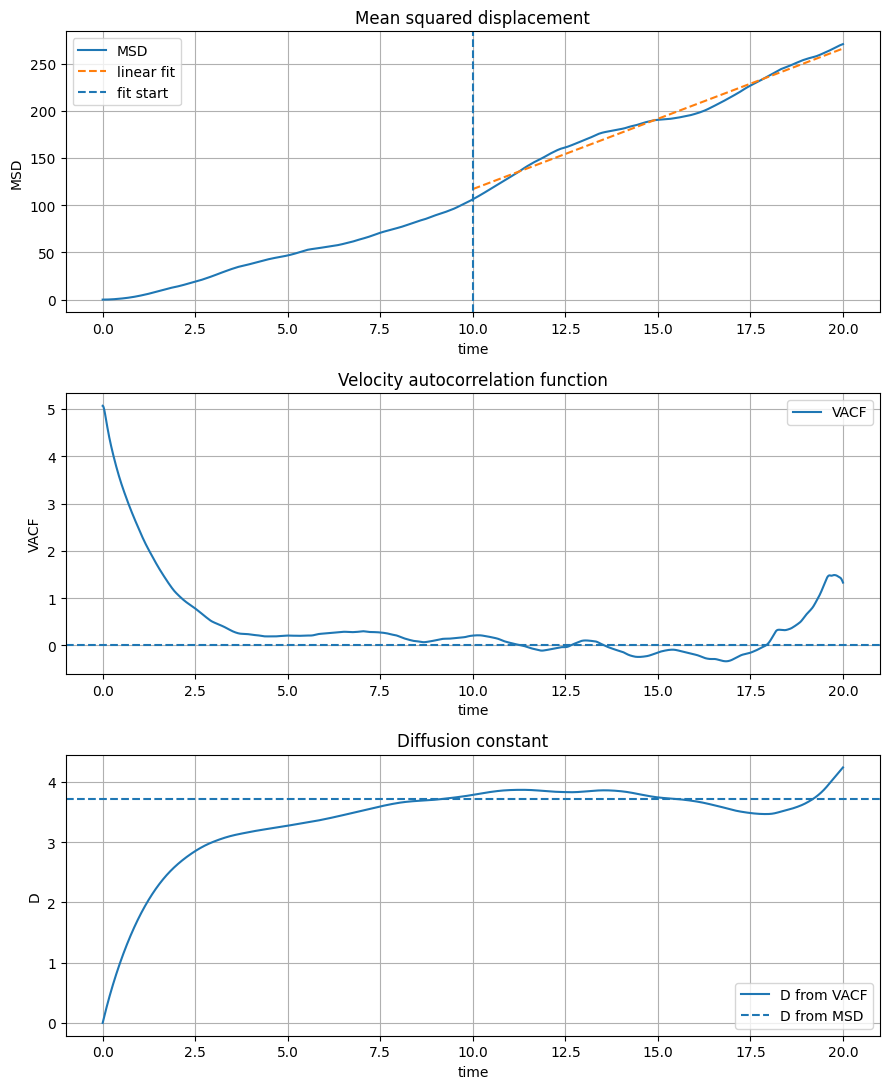

In [ ]:
# %%
fig, axs = plt.subplots(3, 1, figsize=(9, 11))


# plot MSD and linear fit
axs[0].plot(times, msd, label="MSD")
axs[0].plot(times[idxStart:], msd_fit[idxStart:], "--", label="linear fit")
axs[0].axvline(times[idxStart], linestyle="--", label="fit start")

axs[0].set_xlabel("time")
axs[0].set_ylabel("MSD")
axs[0].set_title("Mean squared displacement")
axs[0].legend()
axs[0].grid()


# plot VACF
axs[1].plot(times, vac, label="VACF")
axs[1].axhline(0.0, linestyle="--")

axs[1].set_xlabel("time")
axs[1].set_ylabel("VACF")
axs[1].set_title("Velocity autocorrelation function")
axs[1].legend()
axs[1].grid()


# plot diffusion constant from VACF and compare with MSD result
axs[2].plot(times, D_VACF, label="D from VACF")
axs[2].axhline(D_MSD, linestyle="--", label="D from MSD")

axs[2].set_xlabel("time")
axs[2].set_ylabel("D")
axs[2].set_title("Diffusion constant")
axs[2].legend()
axs[2].grid()


plt.tight_layout()
plt.show()